# FutFlow

## Part 0: Importing Libraries

In [17]:
from abc import ABC, abstractmethod
from typing import Optional, List, Type, Tuple, Dict, Sequence
from __future__ import annotations # Default behaviour in Python 3.11.
import math
import random

import numpy as np
np.set_printoptions(suppress=True) # Disabling scientific notation for NumPy arrays.
from matplotlib import pyplot as plt
from matplotlib.axes._axes import Axes
import matplotlib.dates as mdates
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd
import pyreadr

import torch
# from torchview import draw_graph
torch.set_printoptions(sci_mode=False, precision=6) # Disabling scientific notation for PyTorch tensors.
import torch.nn as nn
import torch.distributions as D
from torch.utils.data import TensorDataset, DataLoader
from torch.func import vmap, jacrev
from tqdm import tqdm

device = torch.device('mps')

## Part 1: Futures Data

### Data Preprocessing

In [18]:
# Loading data.
futures_data = pd.read_csv("nymex_wti_futures.csv")

# Column selection and renaming.
futures_data = (
    futures_data
        .rename(columns={
            "Date": "date",
            "Settlement Price": "price",
            "Time to maturity": "time_to_maturity",
            "Mname": "contract"
        })
        [["date", "price", "time_to_maturity", "contract"]]
)

# Ensuring ´data´ is datetime.
futures_data["date"] = pd.to_datetime(futures_data["date"])

# Maturity ordering via ordered categorical encoding.
maturity_order = [
    "M1", "M2", "M3", "M4", "M5", "M6", "M7",
    "Q1", "Q2", "Q3",
    "Y1", "Y2", "Y3"
]

futures_data["contract"] = pd.Categorical(
    futures_data["contract"],
    categories=maturity_order,
    ordered=True
)

# Sorting by date, then by maturity.
futures_data = futures_data.sort_values(["date", "contract"])

# Sanity checking: Exactly 13 rows per date.
counts = futures_data.groupby("date").size()
assert counts.nunique() == 1 and counts.iloc[0] == 13

# Extracting numerical columns.
values = futures_data[["price", "time_to_maturity"]].values

In [19]:
# From futures_data, creating X_np with all the prices and time to maturities but not data.
# Reshaping.
num_dates = futures_data["date"].nunique()
X_np = values.reshape(num_dates, 13, 2) # (3314, 13, 2)
# 📌 The final futures_data is a tabular data and it is a data frame.

### Futures Surface

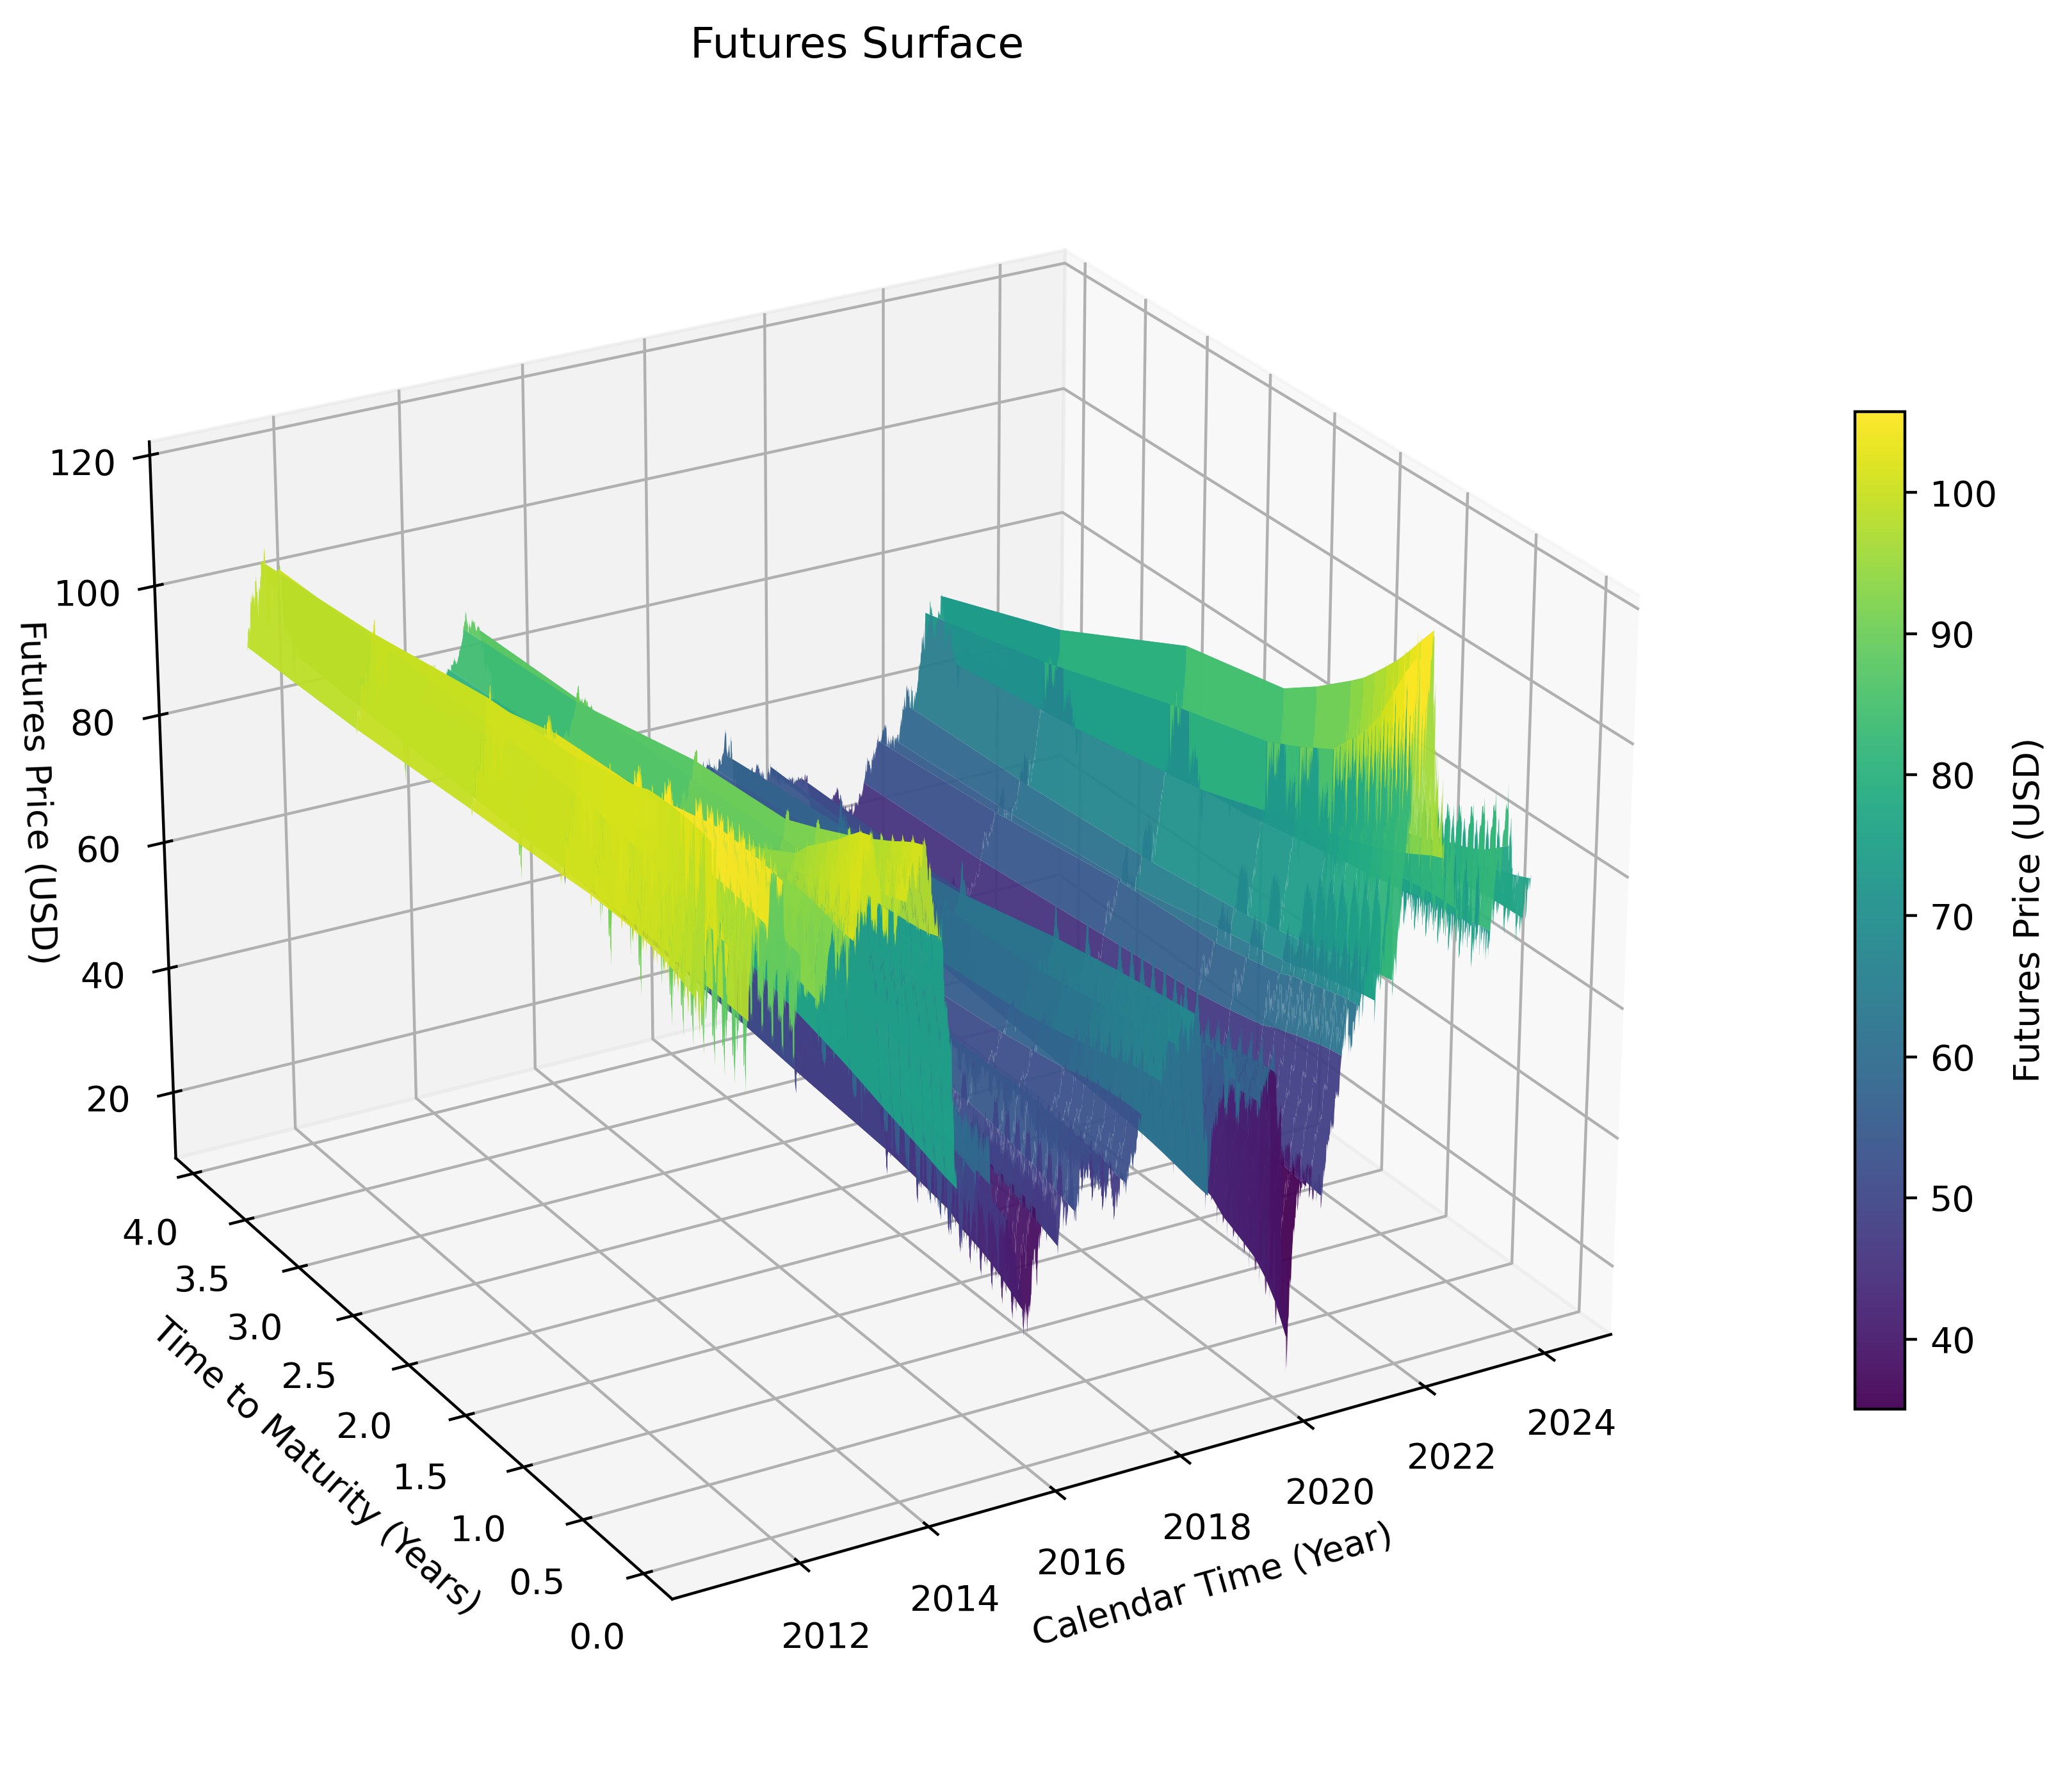

In [20]:
# Extract unique dates (one per time index)
dates = futures_data["date"].drop_duplicates().values
assert len(dates) == X_np.shape[0]

# Convert dates for matplotlib
dates_num = mdates.date2num(dates)

# Time to maturity (fixed grid across time)
ttm = X_np[0, :, 1]               # (13,)

# Futures prices
prices = X_np[:, :, 0]            # (3314, 13)

# Meshgrid: {date, maturity}
TIME, TTM = np.meshgrid(dates_num, ttm, indexing="ij")

# =========================
# Plot
# =========================

fig = plt.figure(figsize=(22, 7), dpi=400)
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    TIME,
    TTM,
    prices,
    cmap="viridis",
    linewidth=0,
    antialiased=True,
    alpha=0.95
)

# Colorbar (pushed right)
cbar = fig.colorbar(
    surf,
    ax=ax,
    shrink=0.6,
    pad=0.03
)
cbar.set_label("Futures Price (USD)")

# Axis labels
ax.set_xlabel("Calendar Time (Year)") # or dates?
ax.set_ylabel("Time to Maturity (Years)")
ax.set_zlabel("Futures Price (USD)")
ax.zaxis.labelpad = 1

# X-axis: show every second year
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

# Camera angle (paper-like)
# ax.view_init(elev=25, azim=-135)
ax.view_init(elev=25, azim=-120)  # slightly rotation to right.

# Title
ax.set_title("Futures Surface")

plt.tight_layout()
plt.show()

### Infrastructure-Ready Data
This is used to convert to PyTorch and into a shape that fit the code infrastructure.

In [21]:
X = torch.tensor(X_np, dtype=torch.float32).unsqueeze(1) # Adding dimension for shape compatiability with code infrastructure.
X = X.to(device)

In [22]:
X[1]

tensor([[[89.379997,  0.043651],
         [90.419998,  0.130952],
         [91.320000,  0.210317],
         [92.070000,  0.289683],
         [92.629997,  0.376984],
         [93.059998,  0.460317],
         [93.330002,  0.539683],
         [93.510002,  0.630952],
         [93.790001,  0.880952],
         [93.580002,  1.126984],
         [92.930000,  1.876984],
         [91.760002,  2.884921],
         [91.360001,  3.884921]]], device='mps:0')

In [23]:
### Data for Full-Data Training ###
eps = 1e-8
X_mean = X.mean(dim=0, keepdim=True)
X_std_dev  = X.std(dim=0, keepdim=True)
X_stdzd = (X - X_mean) / (X_std_dev + eps) # 📌 Epsilon is added.
# Creating consecutive pairs (Xₜ, Xᵤ), u=t+1.
X_t = X[:-1]   # (3313, 1, 13, 2)
X_u = X[1:]
X_t_stdzd = X_stdzd[:-1]
X_u_stdzd = X_stdzd[1:]

In [24]:
# Pairing.
Y = X[:-1]                  # Shape: [3313, 1, 13, 2]  → dates 0 to 3312
Z = X[1:]                   # Shape: [3313, 1, 13, 2]  → dates 1 to 3313
Z = Z[:, :, :, :1]          # Shape: [3313, 1, 13, 1]  → keep only first feature (price)

In [25]:
# 80-20 splitting.
num_singles = X.shape[0]            # 3314
num_pairs = num_singles - 1         # 3313
train_end = int(0.8 * num_pairs)

Y_train,  Z_train  =  Y[:train_end],  Z[:train_end]
Y_test,   Z_test   =  Y[train_end:],  Z[train_end:]

In [26]:
# Standardizing.
eps = 1e-8
# stats for Y = (price, tau)  -> shape (1,1,13,2)
Y_mean = Y_train.mean(dim=0, keepdim=True)
Y_std_dev  = Y_train.std(dim=0, keepdim=True)

Y_train_stdzd = (Y_train - Y_mean) / (Y_std_dev + eps)
Y_test_stdzd  = (Y_test  - Y_mean) / (Y_std_dev + eps)

# stats for Z = price only -> shape (1,1,13,1)
Z_mean = Z_train.mean(dim=0, keepdim=True)
Z_std_dev  = Z_train.std(dim=0, keepdim=True)

Z_train_stdzd = (Z_train - Z_mean) / (Z_std_dev + eps)
Z_test_stdzd  = (Z_test  - Z_mean) / (Z_std_dev + eps)

## Part 2: Object-Oriented Infrastructure 

<span style="color:red"> **This infrastructure remains unchanged when the neural network architecture is modified.**</span>



In [27]:
class Sampleable(ABC):
    """
    Distribution which can be sampled from
    """ 
    @abstractmethod
    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        Args:
            - num_samples: the desired number of samples
        Returns:
            - samples: shape (batch_size, ...)
            - labels: shape (batch_size, label_dim)
        """
        pass

In [28]:
class IsotropicGaussian(nn.Module, Sampleable):
    """
    Sampleable wrapper around torch.randn
    """
    def __init__(self, shape: List[int], std: float = 1.0):
        """
        shape: shape of sampled data
        """
        super().__init__()
        self.shape = shape
        self.std = std
        self.dummy = nn.Buffer(torch.zeros(1)) # Will automatically be moved when self.to(...) is called...
        
    def sample(self, num_samples) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.std * torch.randn(num_samples, *self.shape).to(self.dummy.device), None

In [29]:
class ConditionalProbabilityPath(nn.Module, ABC):
    """
    Abstract base class for conditional probability paths
    """
    def __init__(self, p_simple: Sampleable, p_data: Sampleable):
        super().__init__()
        self.p_simple = p_simple
        self.p_data = p_data

    def sample_marginal_path(self, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the marginal distribution p_t(x) = p_t(x|z) p(z)
        Args:
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - x: samples from p_t(x), (num_samples, c, h, w)
        """
        num_samples = t.shape[0]
        # Sample conditioning variable z ~ p(z)
        z, _ = self.sample_conditioning_variable(num_samples) # (num_samples, c, h, w)
        # Sample conditional probability path x ~ p_t(x|z)
        x = self.sample_conditional_path(z, t) # (num_samples, c, h, w)
        return x

    @abstractmethod
    def sample_conditioning_variable(self, num_samples: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Samples the conditioning variable z and label y
        Args:
            - num_samples: the number of samples
        Returns:
            - z: (num_samples, c, h, w)
            - y: (num_samples, label_dim)
        """
        pass
    
    @abstractmethod
    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the conditional distribution p_t(x|z)
        Args:
            - z: conditioning variable (num_samples, c, h, w)
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - x: samples from p_t(x|z), (num_samples, c, h, w)
        """
        pass
        
    @abstractmethod
    def conditional_vector_field(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional vector field u_t(x|z)
        Args:
            - x: position variable (num_samples, c, h, w)
            - z: conditioning variable (num_samples, c, h, w)
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - conditional_vector_field: conditional vector field (num_samples, c, h, w)
        """ 
        pass

    @abstractmethod
    def conditional_score(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional score of p_t(x|z)
        Args:
            - x: position variable (num_samples, c, h, w)
            - z: conditioning variable (num_samples, c, h, w)
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - conditional_score: conditional score (num_samples, c, h, w)
        """ 
        pass

In [30]:
class Alpha(ABC):
    def __init__(self):
        
        # Check alpha_t(0) = 0
        assert torch.allclose(
            self(torch.zeros(1,1,1,1)), torch.zeros(1,1,1,1)
        )
        # Check alpha_1 = 1
        assert torch.allclose(
            self(torch.ones(1,1,1,1)), torch.ones(1,1,1,1)
        )
        
    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates alpha_t. Should satisfy: self(0.0) = 0.0, self(1.0) = 1.0.
        Args:
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - alpha_t (num_samples, 1, 1, 1)
        """ 
        pass

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - d/dt alpha_t (num_samples, 1, 1, 1)
        """ 
        t = t.unsqueeze(1)
        dt = vmap(jacrev(self))(t)
        return dt.view(-1, 1, 1, 1)
    
class Beta(ABC):
    def __init__(self):
        # Check beta_0 = 1
        assert torch.allclose(
            self(torch.zeros(1,1,1,1)), torch.ones(1,1,1,1)
        )
        # Check beta_1 = 0
        assert torch.allclose(
            self(torch.ones(1,1,1,1)), torch.zeros(1,1,1,1)
        )
        
    @abstractmethod
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates alpha_t. Should satisfy: self(0.0) = 1.0, self(1.0) = 0.0.
        Args:
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - beta_t (num_samples, 1, 1, 1)
        """ 
        pass 

    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt beta_t.
        Args:
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - d/dt beta_t (num_samples, 1, 1, 1)
        """ 
        t = t.unsqueeze(1)
        dt = vmap(jacrev(self))(t)
        return dt.view(-1, 1, 1, 1)

class LinearAlpha(Alpha):
    """
    Implements alpha_t = t
    """
    
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - alpha_t (num_samples, 1, 1, 1)
        """ 
        return t
    
    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - d/dt alpha_t (num_samples, 1, 1, 1)
        """ 
        return torch.ones_like(t)
        
class LinearBeta(Beta):
    """
    Implements beta_t = 1-t
    """
    def __call__(self, t: torch.Tensor) -> torch.Tensor:
        """
        Args:
            - t: time (num_samples, 1)
        Returns:
            - beta_t (num_samples, 1)
        """ 
        return 1-t
        
    def dt(self, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates d/dt alpha_t.
        Args:
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - d/dt alpha_t (num_samples, 1, 1, 1)
        """ 
        return - torch.ones_like(t)
    
class GaussianConditionalProbabilityPath(ConditionalProbabilityPath):
    def __init__(self, p_data: Sampleable, p_simple_shape: List[int], alpha: Alpha, beta: Beta):
        p_simple = IsotropicGaussian(shape = p_simple_shape, std = 1.0)
        super().__init__(p_simple, p_data)
        self.alpha = alpha
        self.beta = beta

    def sample_conditioning_variable(self, num_samples: int) -> torch.Tensor:
        """
        Samples the conditioning variable z and label y
        Args:
            - num_samples: the number of samples
        Returns:
            - z: (num_samples, c, h, w)
            - y: (num_samples, label_dim)
        """
        return self.p_data.sample(num_samples)
    
    def sample_conditional_path(self, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Samples from the conditional distribution p_t(x|z)
        Args:
            - z: conditioning variable (num_samples, c, h, w)
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - x: samples from p_t(x|z), (num_samples, c, h, w)
        """
        return self.alpha(t) * z + self.beta(t) * torch.randn_like(z)
        
    def conditional_vector_field(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional vector field u_t(x|z)
        Args:
            - x: position variable (num_samples, c, h, w)
            - z: conditioning variable (num_samples, c, h, w)
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - conditional_vector_field: conditional vector field (num_samples, c, h, w)
        """ 
        alpha_t = self.alpha(t) # (num_samples, 1, 1, 1)
        beta_t = self.beta(t) # (num_samples, 1, 1, 1)
        dt_alpha_t = self.alpha.dt(t) # (num_samples, 1, 1, 1)
        dt_beta_t = self.beta.dt(t) # (num_samples, 1, 1, 1)

        return (dt_alpha_t - dt_beta_t / beta_t * alpha_t) * z + dt_beta_t / beta_t * x

    def conditional_score(self, x: torch.Tensor, z: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        """
        Evaluates the conditional score of p_t(x|z)
        Args:
            - x: position variable (num_samples, c, h, w)
            - z: conditioning variable (num_samples, c, h, w)
            - t: time (num_samples, 1, 1, 1)
        Returns:
            - conditional_score: conditional score (num_samples, c, h, w)
        """ 
        alpha_t = self.alpha(t)
        beta_t = self.beta(t)
        return (z * alpha_t - x) / beta_t ** 2

In [31]:
class ODE(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor, **kwargs) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: state at time t, shape (bs, c, h, w)
            - t: time, shape (bs, 1)
        Returns:
            - drift_coefficient: shape (bs, c, h, w)
        """
        pass

class SDE(ABC):
    @abstractmethod
    def drift_coefficient(self, xt: torch.Tensor, t: torch.Tensor, **kwargs) -> torch.Tensor:
        """
        Returns the drift coefficient of the ODE.
        Args:
            - xt: state at time t, shape (bs, c, h, w)
            - t: time, shape (bs, 1, 1, 1)
        Returns:
            - drift_coefficient: shape (bs, c, h, w)
        """
        pass

    @abstractmethod
    def diffusion_coefficient(self, xt: torch.Tensor, t: torch.Tensor, **kwargs) -> torch.Tensor:
        """
        Returns the diffusion coefficient of the ODE.
        Args:
            - xt: state at time t, shape (bs, c, h, w)
            - t: time, shape (bs, 1, 1, 1)
        Returns:
            - diffusion_coefficient: shape (bs, c, h, w)
        """
        pass

In [32]:
class Simulator(ABC):
    @abstractmethod
    def step(self, xt: torch.Tensor, t: torch.Tensor, dt: torch.Tensor, **kwargs):
        """
        Takes one simulation step
        Args:
            - xt: state at time t, shape (bs, c, h, w)
            - t: time, shape (bs, 1, 1, 1)
            - dt: time, shape (bs, 1, 1, 1)
        Returns:
            - nxt: state at time t + dt (bs, c, h, w)
        """
        pass

    @torch.no_grad()
    def simulate(self, x: torch.Tensor, ts: torch.Tensor, **kwargs):
        """
        Simulates using the discretization gives by ts
        Args:
            - x_init: initial state, shape (bs, c, h, w)
            - ts: timesteps, shape (bs, nts, 1, 1, 1)
        Returns:
            - x_final: final state at time ts[-1], shape (bs, c, h, w)
        """
        nts = ts.shape[1]
        for t_idx in tqdm(range(nts - 1)):
            t = ts[:, t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h, **kwargs)
        return x

    @torch.no_grad()
    def simulate_with_trajectory(self, x: torch.Tensor, ts: torch.Tensor, **kwargs):
        """
        Simulates using the discretization gives by ts
        Args:
            - x: initial state, shape (bs, c, h, w)
            - ts: timesteps, shape (bs, nts, 1, 1, 1)
        Returns:
            - xs: trajectory of xts over ts, shape (batch_size, nts, c, h, w)
        """
        xs = [x.clone()]
        nts = ts.shape[1]
        for t_idx in tqdm(range(nts - 1)):
            t = ts[:,t_idx]
            h = ts[:, t_idx + 1] - ts[:, t_idx]
            x = self.step(x, t, h, **kwargs)
            xs.append(x.clone())
        return torch.stack(xs, dim=1)

class EulerSimulator(Simulator):
    def __init__(self, ode: ODE):
        self.ode = ode
        
    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor, **kwargs):
        return xt + self.ode.drift_coefficient(xt,t, **kwargs) * h

class EulerMaruyamaSimulator(Simulator):
    def __init__(self, sde: SDE):
        self.sde = sde
        
    def step(self, xt: torch.Tensor, t: torch.Tensor, h: torch.Tensor, **kwargs):
        return xt + self.sde.drift_coefficient(xt,t, **kwargs) * h + self.sde.diffusion_coefficient(xt,t, **kwargs) * torch.sqrt(h) * torch.randn_like(xt)

def record_every(num_timesteps: int, record_every: int) -> torch.Tensor:
    """
    Compute the indices to record in the trajectory given a record_every parameter
    """
    if record_every == 1:
        return torch.arange(num_timesteps)
    return torch.cat(
        [
            torch.arange(0, num_timesteps - 1, record_every),
            torch.tensor([num_timesteps - 1]),
        ]
    )

In [33]:
MiB = 1024 ** 2

def model_size_b(model: nn.Module) -> int:
    """
    Returns model size in bytes. Based on https://discuss.pytorch.org/t/finding-model-size/130275/2
    Args:
    - model: self-explanatory
    Returns:
    - size: model size in bytes
    """
    size = 0
    for param in model.parameters():
        size += param.nelement() * param.element_size()
    for buf in model.buffers():
        size += buf.nelement() * buf.element_size()
    return size

class Trainer(ABC):
    def __init__(self, model: nn.Module):
        super().__init__()
        self.model = model

    @abstractmethod
    def get_train_loss(self, **kwargs) -> torch.Tensor:
        pass

    def get_optimizer(self, lr: float):
        return torch.optim.Adam(self.model.parameters(), lr=lr)

    def train(self, num_epochs: int, device: torch.device, lr: float = 1e-3, **kwargs) -> torch.Tensor:
        # Report model size
        size_b = model_size_b(self.model)
        print(f'Training model with size: {size_b / MiB:.3f} MiB')
        
        # Start
        self.model.to(device)
        opt = self.get_optimizer(lr)
        self.model.train()

        # Train loop
        pbar = tqdm(enumerate(range(num_epochs)))
        for idx, epoch in pbar:
            opt.zero_grad()
            loss = self.get_train_loss(**kwargs)
            loss.backward()
            opt.step()
            pbar.set_description(f'Epoch {idx}, loss: {loss.item():.3f}')

        # Finish
        self.model.eval()

In [34]:
class FuturesPairSampler(nn.Module, Sampleable):
    """
    Sampleable wrapper for futures curve forecasting.

    Returns:
    - z: target samples (batch_size, 1, 13, 1)   # next-day prices
    - y: conditioning labels (batch_size, 1, 13, 2)  # current-day curve
    """
    def __init__(self, Z: torch.Tensor, Y: torch.Tensor):
        super().__init__()
        assert Z.ndim == 4 and Z.shape[1:] == (1, 13, 1), \
            f"Z must have shape (N,1,13,1), got {Z.shape}"
        assert Y.ndim == 4 and Y.shape[1:] == (1, 13, 2), \
            f"Y must have shape (N,1,13,2), got {Y.shape}"
        assert Z.shape[0] == Y.shape[0], \
            "Z and Y must have same number of samples"

        self.Z = Z
        self.Y = Y
        self.dummy = nn.Buffer(torch.zeros(1)) # device helper

    def sample(self, num_samples: int) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """
        Args:
            num_samples: number of samples to draw

        Returns:
            z: target samples (batch_size, 1, 13, 1)   # next-day prices
            y: conditioning labels (batch_size, 1, 13, 2)  # current-day curve
        """     
        if num_samples > self.Y.shape[0]:
            raise ValueError(f"num_samples exceeds dataset size: {self.Y.shape[0]}")

        idx = torch.randperm(self.Y.shape[0], device=self.Y.device)[:num_samples]
        z = self.Z[idx].to(self.dummy.device)
        y = self.Y[idx].to(self.dummy.device)
        return z, y

In [35]:
class ConditionalVectorField(nn.Module, ABC):
    """
    Learned vector field μₜ(x;θ|y).
    """

    @abstractmethod
    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor):
        """
        Args:
        - x: (bs, c, h, w) # in FutFlow (bs, 1, 13, 1)
        - t: (bs, 1, 1, 1)
        - y: (bs, c, h, w) # in FutFlow (bs, 1, 13, 2)
        Returns:
        - u_t^theta(x|y): (bs, c, h, w) # in FutFlow (bs, 1, 13, 1)
        """
        raise NotImplementedError

class VectorFieldODE(ODE):
    def __init__(self, net: ConditionalVectorField):
        self.net = net

    def drift_coefficient(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        """
        Args:
        - x: (bs, c, h, w) # in FutFlow (bs, 1, 13, 1)
        - t: (bs, 1, 1, 1)
        - y: (bs, c, h, w) # in FutFlow (bs, 1, 13, 2)
        """
        return self.net(x, t, y)

In [36]:
class FutFlowTrainer(Trainer):
    def __init__(self, path: GaussianConditionalProbabilityPath, model: ConditionalVectorField, **kwargs):
        super().__init__(model, **kwargs)
        self.path = path

    def get_train_loss(self, batch_size: int) -> torch.Tensor:
        # Step 1: Sample z, y from p_data
        z, y = self.path.p_data.sample(batch_size) # (bs, c, h, w), (bs, c, h, w)

        # Step 2: Sample t ∼ U[0,1] and x ~ pₜ(x|z)
        t = torch.rand(batch_size, 1, 1, 1, device=z.device) # (bs, 1, 1, 1)
        x = self.path.sample_conditional_path(z, t)   # (bs, 1, 13, 1)

        # Step 3: Regress guided neural vector field to conditional target vector field and output loss.
        guided_neural_vector_field = self.model(x, t, y) # (bs, 1, 13, 1).
        conditional_target_vector_field = self.path.conditional_vector_field(x, z, t)  # (bs, 1, 13, 1)
        loss_per_sample  = (guided_neural_vector_field - conditional_target_vector_field).pow(2).flatten(1).sum(dim=1)  # (bs,)
        return loss_per_sample.mean()

## Part 3: Neural Network Architecture

In [39]:
class FourierEncoder(nn.Module):
    """Fourier time embedding for t in [0,1]."""
    def __init__(self, dim: int):
        super().__init__()
        assert dim % 2 == 0
        self.half_dim = dim // 2
        self.weights = nn.Parameter(torch.randn(1, self.half_dim))

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        t = t.view(-1, 1)  # (bs,1)
        freqs = t * self.weights * 2 * math.pi
        return torch.cat([torch.sin(freqs), torch.cos(freqs)], dim=-1) * math.sqrt(2.0)


class ResidualMLPBlock(nn.Module):
    def __init__(self, width: int, dropout: float = 0.0):
        super().__init__()
        self.norm = nn.LayerNorm(width)
        self.ff = nn.Sequential(
            nn.Linear(width, 4 * width),
            nn.SiLU(),
            nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
            nn.Linear(4 * width, width),
        )
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # pre-norm residual block
        h = self.norm(x)
        h = self.ff(h)
        return x + self.dropout(h)


class FutFlowNet(nn.Module):  # or (ConditionalVectorField) if you keep that base class
    """
    Vector field u_theta(x,t|y) for FutFlow (prices-only state).

    x: (bs,1,13,1)
    t: (bs,1,1,1)
    y: (bs,1,13,2)
    out: (bs,1,13,1)
    """
    def __init__(
        self,
        width: int = 512,
        depth: int = 6,
        t_embed_dim: int = 40,
        y_embed_dim: int = 128,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.time_embedder = FourierEncoder(t_embed_dim)

        # y: (bs,1,13,2) -> (bs,26) -> (bs,y_embed_dim)
        self.y_embedder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(26, y_embed_dim),
            nn.SiLU(),
            nn.Linear(y_embed_dim, y_embed_dim),
            nn.SiLU(),
        )

        in_dim = 13 + t_embed_dim + y_embed_dim

        self.in_proj = nn.Sequential(
            nn.Linear(in_dim, width),
            nn.SiLU(),
        )

        self.blocks = nn.ModuleList([ResidualMLPBlock(width, dropout=dropout) for _ in range(depth)])

        self.out_norm = nn.LayerNorm(width)
        self.out_head = nn.Linear(width, 13)

        # small init helps stability for flow fields
        nn.init.zeros_(self.out_head.weight)
        nn.init.zeros_(self.out_head.bias)

    def forward(self, x: torch.Tensor, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        bs = x.shape[0]
        x_flat = x.view(bs, 13)             # (bs,13)
        t_emb = self.time_embedder(t)       # (bs,t_embed_dim)
        y_emb = self.y_embedder(y)          # (bs,y_embed_dim)

        h = torch.cat([x_flat, t_emb, y_emb], dim=1)  # (bs,in_dim)
        h = self.in_proj(h)                            # (bs,width)

        for blk in self.blocks:
            h = blk(h)

        h = self.out_norm(h)
        out = self.out_head(h)                         # (bs,13)
        return out.view(bs, 1, 13, 1)

## Part 4: Training the Neural-Network Vector Field

In [38]:
seed = 123
torch.manual_seed(seed)
if device.type == "mps":
    torch.mps.manual_seed(seed)
random.seed(seed); np.random.seed(seed)

# p_data_train = FuturesPairSampler(X_u_stdzd[:,:,:,:1], X_t_stdzd).to(device) # Full-set model.
p_data_train = FuturesPairSampler(Z_train_stdzd, Y_train_stdzd).to(device) # Train-set model.

path = GaussianConditionalProbabilityPath(
    p_data=p_data_train,
    p_simple_shape=[1, 13, 1],
    alpha=LinearAlpha(),
    beta=LinearBeta()
).to(device)


net = FutFlowNet(
    width=512, # Try to change this to something lower. It is quite high now.
    depth=6,
    t_embed_dim=40,
    y_embed_dim=128,
    dropout=0.0,
).to(device)

trainer = FutFlowTrainer(path=path, model=net)
# trainer.train(num_epochs=5000, device=device, lr=1e-3, batch_size=250)
trainer.train(num_epochs=5000, device=device, lr=3e-4, batch_size=250)

Training model with size: 48.543 MiB


Epoch 4999, loss: 0.515: : 5000it [01:58, 42.34it/s]


## Part 5: Generating Next-Day Sutures Curves
Empty.

## Part 6: Tuning
Empty.

## Part 7: Performance Evaluation

### Auxiliaries

In [40]:
@torch.no_grad()
def conditional_futures_curve_mean(
    *,
    Y_cond: torch.Tensor,          # (N, 1, 13, 2) conditioning curves (STANDARDIZED)
    neural_vector_field,           # trained ConditionalVectorField
    path,                          # GaussianConditionalProbabilityPath
    device,
    Z_mean: torch.Tensor,          # (1, 1, 13, 1) computed from TRAIN
    Z_std_dev: torch.Tensor,       # (1, 1, 13, 1) computed from TRAIN
    eps: float = 1e-8,
    return_unstandardized: bool = True,
    K: int = 50,
    num_ode_steps: int = 200,
    seed: int | None = 123,
):
    """
    Monte Carlo approximation of E[Z_{t+1} | Y_t].

    Returns:
        x1_mc_mean: (N, 1, 13, 1)
            - unstandardized prices if return_unstandardized=True
            - standardized prices otherwise
    """

    if seed is not None:
        torch.manual_seed(seed)
        if device.type == "mps":
            torch.mps.manual_seed(seed)

    Y_cond = Y_cond.to(device)
    neural_vector_field = neural_vector_field.to(device)
    neural_vector_field.eval()

    # move stats to device once
    Z_mean = Z_mean.to(device)
    Z_std_dev = Z_std_dev.to(device)

    N = Y_cond.shape[0]

    # ODE + simulator
    ode = VectorFieldODE(neural_vector_field)
    simulator = EulerSimulator(ode)

    # Time grid
    ts = torch.linspace(0, 1, num_ode_steps, device=device)
    ts = ts.view(1, -1, 1, 1, 1).expand(N, -1, 1, 1, 1)

    # Accumulator (STANDARDIZED space)
    x1_mc_sum = torch.zeros(N, 1, 13, 1, device=device)

    for _ in range(K):
        x0, _ = path.p_simple.sample(N)  # should be (N,1,13,1) in standardized space
        x0 = x0.to(device)

        x1 = simulator.simulate(x0, ts, y=Y_cond)  # (N,1,13,1) standardized
        x1_mc_sum += x1

    x1_mc_mean_stdzd = x1_mc_sum / K

    if not return_unstandardized:
        return x1_mc_mean_stdzd

    # Unstandardize: Z = Z_std * (Z_std_dev + eps)  + Z_mean
    x1_mc_mean_unstdzd = x1_mc_mean_stdzd * (Z_std_dev + eps) + Z_mean
    return x1_mc_mean_unstdzd

In [41]:
def temp_perf_mets(
    model_prices: torch.Tensor,   # (N, 1, 13, 1)
    actual_prices: torch.Tensor   # (N, 1, 13, 1)
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Computes temporal out-of-sample performance metrics.

    Metrics:
      1) Curve-level RMSE (scalar)
      2) Contract-level RMSEs (13,)
      3) Curve-level MAE (scalar)
      4) Contract-level MAEs (13,)

    Args:
        model_prices: model-generated prices, shape (N,1,13,1)
        actual_prices: true prices, same shape

    Returns:
        curve_rmse      : ()
        contract_rmses  : (13,)
        curve_mae       : ()
        contract_maes   : (13,)
    """
    # ---- ensure same device
    device = model_prices.device
    actual_prices = actual_prices.to(device)
    
    # ---- reshape to (N, 13)
    model_prices  = model_prices.squeeze(1).squeeze(-1)
    actual_prices = actual_prices.squeeze(1).squeeze(-1)

    # ---- shape checks
    if model_prices.shape != actual_prices.shape:
        raise ValueError("model_prices and actual_prices must have same shape")
    if model_prices.ndim != 2:
        raise ValueError(f"Expected (N,13), got {model_prices.shape}")

    # ---- errors
    error      = model_prices - actual_prices            # (N,13)
    sq_error   = error.pow(2)
    abs_error  = error.abs()

    # ---- RMSEs
    contract_rmses = torch.sqrt(torch.mean(sq_error, dim=0))  # (13,)
    curve_rmse     = torch.sqrt(torch.mean(sq_error))         # ()

    # ---- MAEs
    contract_maes = torch.mean(abs_error, dim=0)              # (13,)
    curve_mae     = torch.mean(abs_error)                     # ()

    return curve_rmse, contract_rmses, curve_mae, contract_maes


# Usage
# curve_rmse, contract_rmses, curve_mae, contract_maes = temp_perf_mets(
#    model_prices=futures_prices_forecast_unstdzd,
#    actual_prices=Z_test
# )

# print("Curve-level RMSE:", curve_rmse.item())
# print("Curve-level MAE :", curve_mae.item())

# print("Contract-level RMSEs:", contract_rmses)
# print("Contract-level MAEs :", contract_maes)

In [42]:
def plot_contract_errors(
    contract_rmses: torch.Tensor,
    contract_maes: torch.Tensor,
    curve_rmse: torch.Tensor | None = None,
    curve_mae: torch.Tensor | None = None,
    labels: list[str] | None = None,
    title: str = "Temporal Out-of-Sample Contract-Level RMSEs and MAEs",
):
    """
    Plot contract-level RMSEs and MAEs across maturities,
    with optional curve-level reference lines.

    Args:
        contract_rmses : (13,) tensor
        contract_maes  : (13,) tensor
        curve_rmse     : scalar tensor or None
        curve_mae      : scalar tensor or None
        labels         : optional list of maturity labels
        title          : plot title
    """

    # Default maturity labels (fixed across dataset)
    if labels is None:
        labels = [
            "M1","M2","M3","M4","M5","M6","M7",
            "Q1","Q2","Q3","Y1","Y2","Y3"
        ]

    # ---- move tensors to CPU
    contract_rmses = contract_rmses.detach().cpu().flatten()
    contract_maes  = contract_maes.detach().cpu().flatten()

    if contract_rmses.numel() != len(labels):
        raise ValueError("contract_rmses length does not match number of labels")
    if contract_maes.numel() != len(labels):
        raise ValueError("contract_maes length does not match number of labels")

    x = list(range(len(labels)))

    plt.figure(figsize=(11, 4.5))

    # Contract-level metrics
    plt.plot(x, contract_rmses.numpy(), marker="o", label="RMSE")
    plt.plot(x, contract_maes.numpy(),  marker="s", label="MAE")

    # Curve-level reference lines
    if curve_rmse is not None:
        plt.axhline(
            curve_rmse.item(),
            linestyle="--",
            linewidth=1.5,
            alpha=0.7,
            label="Curve-level RMSE"
        )

    if curve_mae is not None:
        plt.axhline(
            curve_mae.item(),
            linestyle=":",
            linewidth=1.5,
            alpha=0.7,
            label="Curve-level MAE"
        )

    plt.xticks(x, labels)
    plt.xlabel("Contract")
    plt.ylabel("Prediction Error (USD per barrel)")
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

### Loading Trained Model Parameters

### Out-of-Sample Analysis

#### Curve Check

100%|██████████| 199/199 [00:00<00:00, 667.61it/s]


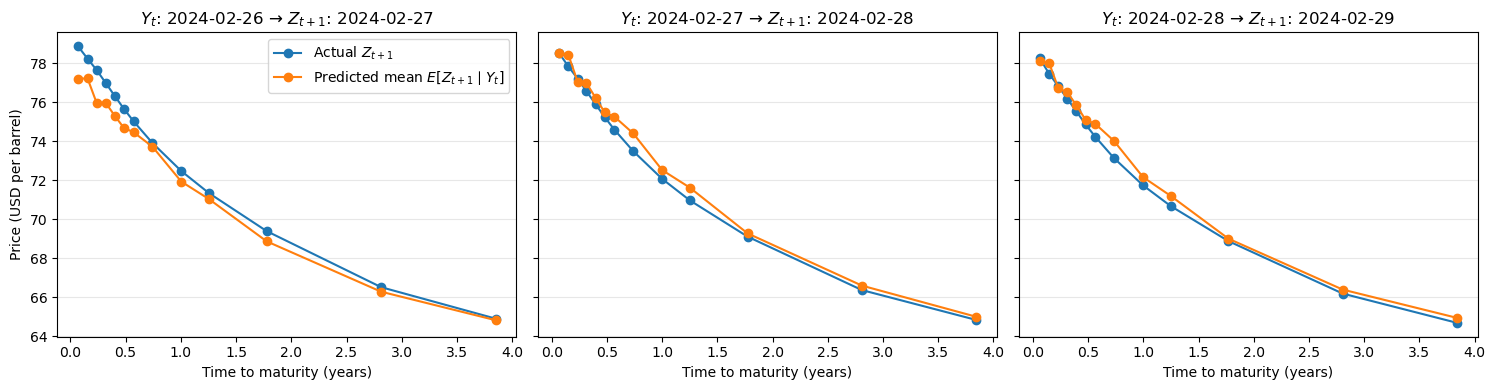

In [43]:
# --- helper: unstandardize tau from Y (price,tau) stats (computed on TRAIN)
def unstandardize_tau(Y_stdzd: torch.Tensor, Y_mean: torch.Tensor, Y_std_dev: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    """
    Y_stdzd: (N,1,13,2) standardized
    returns tau in original units: (N,13)
    """
    tau_std = Y_stdzd[:, 0, :, 1]  # (N,13)
    tau = tau_std * (Y_std_dev[0, 0, :, 1] + eps) + Y_mean[0, 0, :, 1]
    return tau


# =========================
# Dates (aligned correctly)
# =========================
dates = futures_data["date"].drop_duplicates().values
assert len(dates) == X_np.shape[0]

# ensure real datetimes (so formatting works)
dates = pd.to_datetime(dates).to_pydatetime()
dates = np.asarray(dates)

num_singles = len(dates)            # 3314
num_pairs   = num_singles - 1       # 3313
train_end   = int(0.8 * num_pairs)

# dates aligned with Y_t (pair index t) and Z_{t+1}
dates_Y_test = dates[train_end : train_end + len(Y_test_stdzd)]
dates_Z_test = dates[train_end + 1 : train_end + 1 + len(Z_test)]


# ==========================================
# Pick last 3 test points (as you asked)
# ==========================================
Y_cond_3 = Y_test_stdzd[-3:]   # (3,1,13,2) standardized conditioning curve
Z_true_3 = Z_test[-3:]         # (3,1,13,1) unstandardized true next-day prices

dates_Y_3 = dates_Y_test[-3:]
dates_Z_3 = dates_Z_test[-3:]


# ==========================================
# MC mean forecast (returns UNstandardized)
# ==========================================
Z_hat_3 = conditional_futures_curve_mean(
    Y_cond=Y_cond_3,
    neural_vector_field=net,     # or unet, whichever you trained
    path=path,
    device=device,
    Z_mean=Z_mean,
    Z_std_dev=Z_std_dev,
    K=50,
    num_ode_steps=200,
    seed=123,
    return_unstandardized=True,
)  # (3,1,13,1)


# ==========================================
# x-axis: use tau from conditioning curve
# ==========================================
tau_3 = unstandardize_tau(
    Y_cond_3.to(device),
    Y_mean.to(device),
    Y_std_dev.to(device),
).detach().cpu()  # (3,13)

# y-values
pred_prices_3 = Z_hat_3.squeeze(1).squeeze(-1).detach().cpu()   # (3,13)
true_prices_3 = Z_true_3.squeeze(1).squeeze(-1).detach().cpu()  # (3,13)


# ==========================================
# Plot
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

# if matplotlib returns a single Axes (rare here), normalize to list
if not isinstance(axes, (list, np.ndarray)):
    axes = [axes]

for i in range(3):
    ax = axes[i]
    ax.plot(tau_3[i], true_prices_3[i], marker="o", label="Actual $Z_{t+1}$")
    ax.plot(tau_3[i], pred_prices_3[i], marker="o", label="Predicted mean $E[Z_{t+1}\mid Y_t]$")

    ax.set_title(f"$Y_t$: {dates_Y_3[i]:%Y-%m-%d} → $Z_{{t+1}}$: {dates_Z_3[i]:%Y-%m-%d}")
    ax.set_xlabel("Time to maturity (years)")
    ax.grid(True, axis="y", alpha=0.3)

axes[0].set_ylabel("Price (USD per barrel)")
axes[0].legend()
plt.tight_layout()
plt.show()

#### Out-of-Sample Next-Day Futures-Curve Forcasts

In [29]:
# Assume these already exist from training
# ---------------------------------------
# net          : trained ConditionalVectorField (U-Net or MLP)
# path         : GaussianConditionalProbabilityPath (built with TRAIN sampler)
# device       : torch.device("mps") or "cpu"
# Y_test_stdzd : (N_test, 1, 13, 2) standardized conditioning curves
# Z_mean       : (1, 1, 13, 1) TRAIN mean
# Z_std_dev    : (1, 1, 13, 1) TRAIN std

# Monte Carlo conditional mean of next-day futures curves
Z_hat_test = conditional_futures_curve_mean(
    Y_cond=Y_test_stdzd,
    neural_vector_field=net,
    path=path,
    device=device,
    Z_mean=Z_mean,
    Z_std_dev=Z_std_dev,
    K=50,
    num_ode_steps=200,
    return_unstandardized=True,
)

# Z_hat_test shape: (N_test, 1, 13, 1)

100%|██████████| 199/199 [00:00<00:00, 205.70it/s]


#### Temporal Out-of-Sample Performance-Metric Tables

In [30]:
curve_rmse, contract_rmses, curve_mae, contract_maes = temp_perf_mets(
    model_prices=Z_hat_test,
    actual_prices=Z_test
 )

#### Temporal Out-of-Sample Performance-Metric Plots

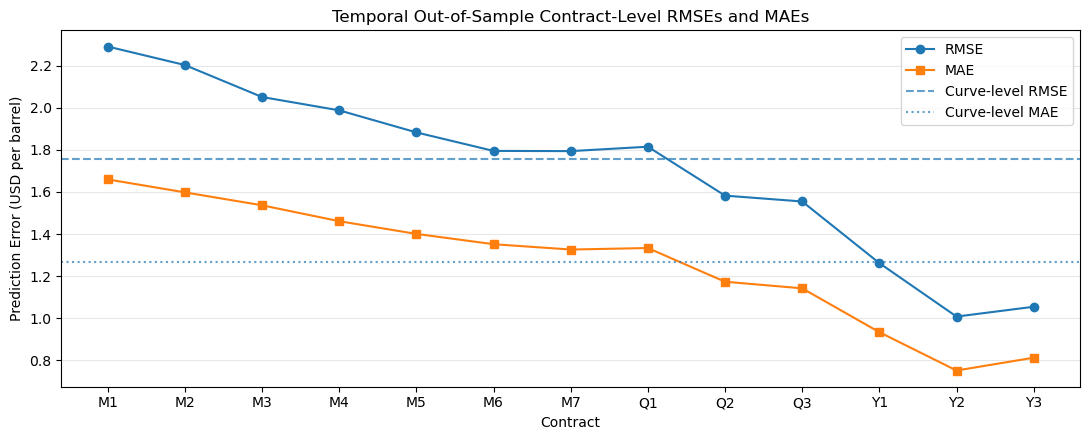

In [31]:
plot_contract_errors(
    contract_rmses=contract_rmses,
    contract_maes=contract_maes,
    curve_rmse=curve_rmse,
    curve_mae=curve_mae,
)

## Part 8: Distributional Diagnostics

In [39]:
@torch.no_grad()
def conditional_futures_curve_samples(
    *,
    Y_cond: torch.Tensor,          # (N, 1, 13, 2) conditioning curves (STANDARDIZED)
    neural_vector_field,           # trained net
    path,                          # GaussianConditionalProbabilityPath
    device,
    Z_mean: torch.Tensor,          # (1,1,13,1) TRAIN mean
    Z_std_dev: torch.Tensor,       # (1,1,13,1) TRAIN std
    eps: float = 1e-8,
    return_unstandardized: bool = True,
    K: int = 200,
    num_ode_steps: int = 200,
    seed: int | None = 123,
    batch_N: int = 128,            # batch over time points
    chunk_K: int = 20,             # chunk over MC draws (keeps memory stable)
) -> torch.Tensor:
    """
    Returns MC samples for each conditioning curve.

    Output:
        samples: (K, N, 1, 13, 1)
            - unstandardized if return_unstandardized=True
            - standardized otherwise
    """
    if seed is not None:
        torch.manual_seed(seed)
        if device.type == "mps":
            torch.mps.manual_seed(seed)

    Y_cond = Y_cond.to(device)
    neural_vector_field = neural_vector_field.to(device)
    neural_vector_field.eval()

    Z_mean = Z_mean.to(device)
    Z_std_dev = Z_std_dev.to(device)

    N = Y_cond.shape[0]

    ode = VectorFieldODE(neural_vector_field)
    simulator = EulerSimulator(ode)

    # precompute time grid template
    ts_template = torch.linspace(0, 1, num_ode_steps, device=device).view(1, -1, 1, 1, 1)

    # store on CPU to avoid GPU memory growth
    samples_out = torch.empty((K, N, 1, 13, 1), device="cpu", dtype=torch.float32)

    for n0 in range(0, N, batch_N):
        n1 = min(N, n0 + batch_N)
        Yb = Y_cond[n0:n1]  # (B,1,13,2)
        B = Yb.shape[0]

        for k0 in range(0, K, chunk_K):
            m = min(chunk_K, K - k0)  # how many draws in this chunk

            # Repeat conditioning curves m times: (m*B,1,13,2)
            Yrep = Yb.unsqueeze(0).expand(m, B, 1, 13, 2).reshape(m * B, 1, 13, 2)

            # Sample x0 for all m*B paths
            x0, _ = path.p_simple.sample(m * B)   # (m*B,1,13,1)
            x0 = x0.to(device)

            ts = ts_template.expand(m * B, -1, 1, 1, 1)
            x1 = simulator.simulate(x0, ts, y=Yrep)  # (m*B,1,13,1) standardized

            if return_unstandardized:
                x1 = x1 * (Z_std_dev + eps) + Z_mean  # unstandardize

            # reshape to (m, B, 1, 13, 1) and write into output
            x1 = x1.reshape(m, B, 1, 13, 1).detach().to("cpu")
            samples_out[k0:k0 + m, n0:n1] = x1

    return samples_out

In [40]:
def interval_coverage_and_width(
    samples: torch.Tensor,          # (K,N,1,13,1) UNstandardized recommended
    actual: torch.Tensor,           # (N,1,13,1) UNstandardized
    levels: Sequence[float] = (0.5, 0.8, 0.95),
    labels: Sequence[str] = ("M1","M2","M3","M4","M5","M6","M7","Q1","Q2","Q3","Y1","Y2","Y3"),
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      coverage_df: rows=levels, cols=contracts
      width_df   : rows=levels, cols=contracts
    """
    # move to numpy for robust quantiles (works regardless of MPS limitations)
    S = samples.squeeze(2).squeeze(-1).numpy()  # (K,N,13)
    A = actual.squeeze(1).squeeze(-1).detach().cpu().numpy()  # (N,13)

    K, N, C = S.shape
    assert C == 13, f"Expected 13 contracts, got {C}"

    coverage = np.zeros((len(levels), C), dtype=np.float64)
    width    = np.zeros((len(levels), C), dtype=np.float64)

    for j, c in enumerate(levels):
        lo_q = (1.0 - c) / 2.0
        hi_q = 1.0 - lo_q

        lo = np.quantile(S, lo_q, axis=0)  # (N,13)
        hi = np.quantile(S, hi_q, axis=0)  # (N,13)

        inside = (A >= lo) & (A <= hi)      # (N,13)

        coverage[j] = inside.mean(axis=0)
        width[j]    = (hi - lo).mean(axis=0)

    coverage_df = pd.DataFrame(coverage, index=list(levels), columns=list(labels))
    width_df    = pd.DataFrame(width,    index=list(levels), columns=list(labels))
    return coverage_df, width_df

In [41]:
def plot_coverage_vs_nominal(coverage_df: pd.DataFrame, title: str = "Coverage vs nominal level"):
    levels = np.array(coverage_df.index, dtype=float)
    avg_cov = coverage_df.mean(axis=1).values

    plt.figure(figsize=(6, 4))
    plt.plot(levels, avg_cov, marker="o", label="Avg across contracts")
    plt.plot(levels, levels, linestyle="--", label="Ideal")
    plt.xlabel("Nominal level")
    plt.ylabel("Empirical coverage")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_width_vs_maturity(width_df: pd.DataFrame, level: float = 0.95, title: str = "Interval width vs maturity"):
    w = width_df.loc[level].values
    labels = width_df.columns.tolist()

    plt.figure(figsize=(10, 4))
    plt.plot(range(len(labels)), w, marker="o")
    plt.xticks(range(len(labels)), labels)
    plt.xlabel("Contract")
    plt.ylabel(f"Avg width ({int(level*100)}% PI)")
    plt.title(title)
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

100%|██████████| 799/799 [00:02<00:00, 266.93it/s]



Empirical coverage (rows=nominal levels):
            M1        M2        M3        M4        M5        M6        M7  \
0.50  0.340875  0.334842  0.292609  0.300151  0.276018  0.282051  0.304676   
0.80  0.582202  0.579186  0.529412  0.576169  0.553544  0.564103  0.567119   
0.95  0.767722  0.749623  0.755656  0.758673  0.726998  0.766214  0.751131   

            Q1        Q2        Q3        Y1        Y2        Y3  
0.50  0.312217  0.289593  0.310709  0.315234  0.336350  0.273002  
0.80  0.508296  0.533937  0.512821  0.539970  0.600302  0.524887  
0.95  0.713424  0.737557  0.711916  0.734540  0.800905  0.745098  

Average interval width (rows=nominal levels):
            M1        M2        M3        M4        M5        M6        M7  \
0.50  1.585030  1.481838  1.414217  1.371839  1.245222  1.310114  1.222469   
0.80  3.018746  2.826651  2.703586  2.614349  2.381704  2.489034  2.336699   
0.95  4.608239  4.335825  4.147431  4.024970  3.648494  3.828201  3.600562   

            Q1  

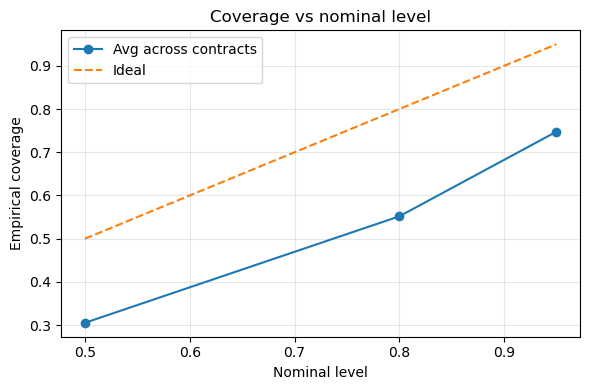

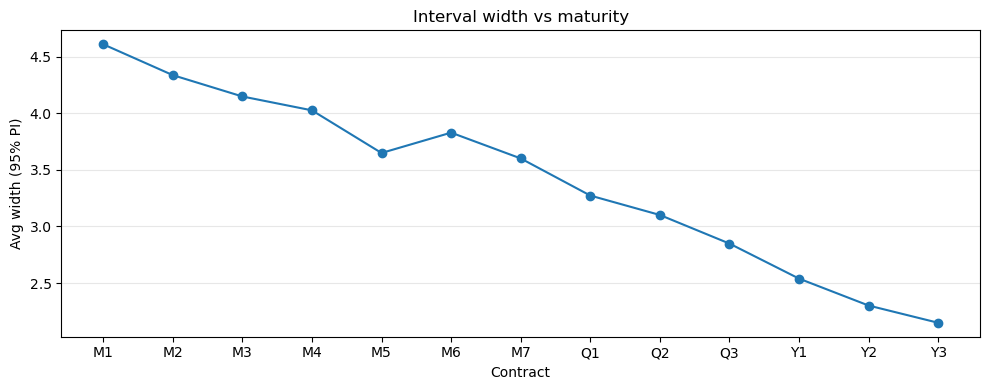

In [59]:
# ===== Part 8: Distributional Diagnostics =====
K_diag = 500          # start here; use 500 for final 95% numbers if runtime allows
num_steps = 800

samples_test = conditional_futures_curve_samples(
    Y_cond=Y_test_stdzd,
    neural_vector_field=net,
    path=path,
    device=device,
    Z_mean=Z_mean,
    Z_std_dev=Z_std_dev,
    K=K_diag,
    num_ode_steps=num_steps,
    return_unstandardized=True,
    seed=123,
    batch_N=128,
    chunk_K=20,
)  # (K,N,1,13,1) unstandardized

coverage_df, width_df = interval_coverage_and_width(
    samples=samples_test,
    actual=Z_test,
    levels=(0.5, 0.8, 0.95),
)

print("\nEmpirical coverage (rows=nominal levels):")
print(coverage_df)

print("\nAverage interval width (rows=nominal levels):")
print(width_df)

plot_coverage_vs_nominal(coverage_df)
plot_width_vs_maturity(width_df, level=0.95)

In [81]:
"""
FutFlow distributional diagnostics (minimal, thesis-ready)

What this script does (given MC samples from FutFlow):
1) Constructs central prediction intervals per day & contract for nominal levels:
   {0.10, 0.20, ..., 0.90, 0.95}
2) Computes empirical coverage and sharpness (avg interval width)
3) Produces tables:
   - Coverage table for all 13 contracts
   - Coverage averaged over all contracts
   - Coverage averaged over maturity buckets (M, Q, Y)
   - Same three tables for sharpness
4) Reliability plot (nominal vs empirical) for:
   - overall average
   - maturity buckets

Assumptions:
- You already have:
  - Y_test_stdzd: (N,1,13,2) standardized conditioning curves
  - Z_test:      (N,1,13,1) unstandardized actual next-day prices
  - net, path, device, Z_mean, Z_std_dev
- You already have the function conditional_futures_curve_samples defined.
"""

from __future__ import annotations

from typing import Sequence, Dict, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

LABELS_13 = ("M1","M2","M3","M4","M5","M6","M7","Q1","Q2","Q3","Y1","Y2","Y3")

BUCKETS: Dict[str, Sequence[str]] = {
    "M (M1–M7)": ("M1","M2","M3","M4","M5","M6","M7"),
    "Q (Q1–Q3)": ("Q1","Q2","Q3"),
    "Y (Y1–Y3)": ("Y1","Y2","Y3"),
}

def make_nominal_levels(include_95: bool = True) -> Tuple[float, ...]:
    levels = [round(x, 2) for x in np.arange(0.10, 0.91, 0.10)]
    if include_95 and 0.95 not in levels:
        levels.append(0.95)
    return tuple(levels)

def _to_numpy_samples_and_actual(
    samples: torch.Tensor,  # (K,N,1,13,1) unstandardized
    actual: torch.Tensor,   # (N,1,13,1) unstandardized
) -> Tuple[np.ndarray, np.ndarray]:
    # samples -> (K,N,13)
    S = samples.detach().cpu().squeeze(2).squeeze(-1).numpy()
    # actual -> (N,13)
    A = actual.detach().cpu().squeeze(1).squeeze(-1).numpy()
    if S.ndim != 3 or S.shape[2] != 13:
        raise ValueError(f"Expected samples shape (K,N,13) after squeeze, got {S.shape}")
    if A.ndim != 2 or A.shape[1] != 13:
        raise ValueError(f"Expected actual shape (N,13) after squeeze, got {A.shape}")
    return S, A

def compute_coverage_and_sharpness(
    samples: torch.Tensor,
    actual: torch.Tensor,
    levels: Sequence[float],
    labels: Sequence[str] = LABELS_13,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Returns:
      coverage_df: rows=levels, cols=contracts
      width_df:    rows=levels, cols=contracts
    """
    S, A = _to_numpy_samples_and_actual(samples, actual)  # S:(K,N,13), A:(N,13)

    coverage = np.zeros((len(levels), 13), dtype=np.float64)
    width    = np.zeros((len(levels), 13), dtype=np.float64)

    for j, c in enumerate(levels):
        if not (0 < c < 1):
            raise ValueError(f"Nominal level must be in (0,1), got {c}")
        lo_q = (1.0 - c) / 2.0
        hi_q = 1.0 - lo_q

        lo = np.quantile(S, lo_q, axis=0)  # (N,13)
        hi = np.quantile(S, hi_q, axis=0)  # (N,13)

        inside = (A >= lo) & (A <= hi)     # (N,13)

        coverage[j] = inside.mean(axis=0)
        width[j]    = (hi - lo).mean(axis=0)

    coverage_df = pd.DataFrame(coverage, index=list(levels), columns=list(labels))
    width_df    = pd.DataFrame(width,    index=list(levels), columns=list(labels))
    return coverage_df, width_df

def summarize_average(df: pd.DataFrame, name: str = "Cross-Contract Average)") -> pd.DataFrame:
    out = pd.DataFrame({name: df.mean(axis=1)})
    out.index.name = "Nominal"
    return out

def summarize_buckets(df: pd.DataFrame, buckets: Dict[str, Sequence[str]] = BUCKETS) -> pd.DataFrame:
    out = pd.DataFrame(index=df.index)
    for bname, cols in buckets.items():
        out[bname] = df.loc[:, list(cols)].mean(axis=1)
    out.index.name = "Nominal"
    return out

def make_coverage_table_all_contracts(coverage_df: pd.DataFrame) -> pd.DataFrame:
    tab = coverage_df.copy()
    tab.index.name = "Nominal"
    return tab

def make_sharpness_table_all_contracts(width_df: pd.DataFrame) -> pd.DataFrame:
    tab = width_df.copy()
    tab.index.name = "Nominal"
    return tab

def reliability_plot(
    coverage_df: pd.DataFrame,
    title: str = "Reliability Plot (Nominal vs. Empirical Coverage)",
    show_buckets: bool = True,
    buckets: Dict[str, Sequence[str]] = BUCKETS,
):
    levels = np.array(coverage_df.index, dtype=float)

    plt.figure(figsize=(7, 5))

    # overall average
    plt.plot(levels, coverage_df.mean(axis=1).values, marker="o", label="Avg (all contracts)")

    if show_buckets:
        for bname, cols in buckets.items():
            plt.plot(levels, coverage_df.loc[:, list(cols)].mean(axis=1).values, marker="o", label=bname)

    # ideal line
    plt.plot(levels, levels, linestyle="--", label="Ideal")

    plt.xlabel("Nominal coverage")
    plt.ylabel("Empirical coverage")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -------------------------
# Main diagnostics runner
# -------------------------

def run_futflow_distributional_diagnostics(
    *,
    Y_cond_stdzd: torch.Tensor,     # (N,1,13,2)
    Z_actual: torch.Tensor,         # (N,1,13,1) unstandardized
    net,
    path,
    device,
    Z_mean: torch.Tensor,
    Z_std_dev: torch.Tensor,
    K: int = 200,
    num_ode_steps: int = 200,
    levels: Sequence[float] | None = None,
    seed: int = 123,
    batch_N: int = 128,
    chunk_K: int = 20,
):
    if levels is None:
        levels = make_nominal_levels(include_95=True)

    # 1) Generate MC samples (unstandardized)
    samples = conditional_futures_curve_samples(
        Y_cond=Y_cond_stdzd,
        neural_vector_field=net,
        path=path,
        device=device,
        Z_mean=Z_mean,
        Z_std_dev=Z_std_dev,
        K=K,
        num_ode_steps=num_ode_steps,
        return_unstandardized=True,
        seed=seed,
        batch_N=batch_N,
        chunk_K=chunk_K,
    )  # (K,N,1,13,1)

    # 2) Coverage + sharpness
    coverage_df, width_df = compute_coverage_and_sharpness(
        samples=samples,
        actual=Z_actual,
        levels=levels,
        labels=LABELS_13,
    )

    # 3) Tables: coverage
    cov_all = make_coverage_table_all_contracts(coverage_df)
    cov_avg = summarize_average(coverage_df, name="Avg (all contracts)")
    cov_bkt = summarize_buckets(coverage_df, buckets=BUCKETS)

    # 4) Tables: sharpness (width)
    wid_all = make_sharpness_table_all_contracts(width_df)
    wid_avg = summarize_average(width_df, name="Avg (all contracts)")
    wid_bkt = summarize_buckets(width_df, buckets=BUCKETS)

    # 5) Print summary tables
    print("\n=== Coverage: all contracts (empirical) ===")
    print(cov_all)

    print("\n=== Coverage: average over contracts ===")
    print(cov_avg)

    print("\n=== Coverage: maturity buckets ===")
    print(cov_bkt)

    print("\n=== Sharpness (avg PI width): all contracts ===")
    print(wid_all)

    print("\n=== Sharpness: average over contracts ===")
    print(wid_avg)

    print("\n=== Sharpness: maturity buckets ===")
    print(wid_bkt)

    # 6) Reliability plot
    reliability_plot(
        coverage_df,
        title=f"Reliability Plot",
        show_buckets=True,
        buckets=BUCKETS,
    )


    return {
        "samples": samples,
        "coverage_all": cov_all,
        "coverage_avg": cov_avg,
        "coverage_buckets": cov_bkt,
        "sharpness_all": wid_all,
        "sharpness_avg": wid_avg,
        "sharpness_buckets": wid_bkt,
    }

# -------------------------
# Example usage (TEST SET)
# -------------------------
# levels = make_nominal_levels(include_95=True)
# results = run_futflow_distributional_diagnostics(
#     Y_cond_stdzd=Y_test_stdzd,
#     Z_actual=Z_test,
#     net=net,
#     path=path,
#     device=device,
#     Z_mean=Z_mean,
#     Z_std_dev=Z_std_dev,
#     K=200,                 # choose for runtime; 500 if you can afford it
#     num_ode_steps=200,     # 200 is typically ok; 800 for best sampling fidelity (slow)
#     levels=levels,
# )

100%|██████████| 199/199 [00:00<00:00, 308.04it/s]



=== Coverage: all contracts (empirical) ===
               M1        M2        M3        M4        M5        M6        M7  \
Nominal                                                                         
0.10     0.067873  0.076923  0.055807  0.054299  0.028658  0.043741  0.057315   
0.20     0.141780  0.143288  0.120664  0.102564  0.082956  0.105581  0.105581   
0.30     0.188537  0.184012  0.161388  0.162896  0.143288  0.164404  0.170437   
0.40     0.266968  0.250377  0.221719  0.232278  0.208145  0.214178  0.236802   
0.50     0.325792  0.325792  0.279035  0.301659  0.269985  0.288084  0.303167   
0.60     0.410256  0.390649  0.351433  0.387632  0.340875  0.361991  0.378582   
0.70     0.484163  0.472097  0.428356  0.475113  0.428356  0.457014  0.457014   
0.80     0.573152  0.567119  0.515837  0.562594  0.544495  0.549020  0.553544   
0.90     0.684766  0.663650  0.656109  0.675716  0.642534  0.680241  0.653092   
0.95     0.746606  0.743590  0.737557  0.748115  0.720965  0.749

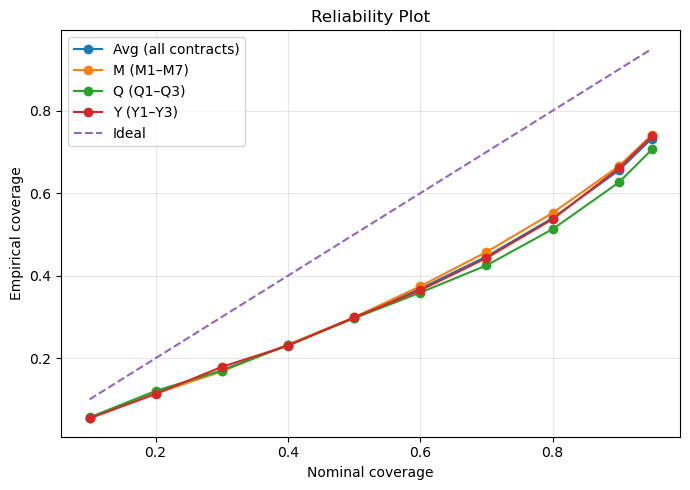

In [82]:
levels = make_nominal_levels(include_95=True)
results = run_futflow_distributional_diagnostics(
   Y_cond_stdzd=Y_test_stdzd,
     Z_actual=Z_test,
     net=net,
     path=path,
     device=device,
     Z_mean=Z_mean,
     Z_std_dev=Z_std_dev,
     K=200,                 # choose for runtime; 500 if you can afford it
     num_ode_steps=200,     # 200 is typically ok; 800 for best sampling fidelity (slow)
     levels=levels  # optional
 )

## Part 9: Numerics

## Part 10: Deliverables

### Interpolating Probability Path

### Graph of Neural Network Architecture